# **EDA: Enhanced audio of accident and crime detection (Kaggle)**

**Fuente:** https://www.kaggle.com/datasets/afisarsy/enhanced-audio-of-accident-and-crime-detection

Dataset de **9.089 archivos WAV de duración variable**, organizado en **13 clases** orientadas a la detección de accidentes y crímenes en entornos urbanos. Es la versión mejorada (preprocesada y aumentada) del dataset en bruto del mismo autor (`raw-audio-of-accident-and-crime-detection`).

## **1. Importaciones y configuración**

In [1]:
# Instalar dependencias necesarias
%pip install librosa soundfile kaggle tqdm seaborn scikit-learn

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import zipfile
import librosa
import librosa.display
import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print('Librerías cargadas.')
print(f'librosa version: {librosa.__version__}')
print(f'numpy  version: {np.__version__}')
print(f'pandas version: {pd.__version__}')

Librerías cargadas.
librosa version: 0.11.0
numpy  version: 2.0.2
pandas version: 2.2.2


In [3]:
# Configuración de estilo
plt.style.use('dark_background')
sns.set_palette('husl')
FIGSIZE = (14, 5)
COLOR_MAP = 'plasma'

## **2. Carga y estructura del dataset**

In [4]:
!mkdir -p ~/.kaggle
!echo KGAT_36aa15fbddafdb930f359d9c0c4cfb71 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
print("Configuración de Kaggle API completada.")

Configuración de Kaggle API completada.


In [5]:
DATASET_SLUG = 'afisarsy/enhanced-audio-of-accident-and-crime-detection'
DOWNLOAD_PATH = './emergencysound'

!kaggle datasets download -d {DATASET_SLUG} -p {DOWNLOAD_PATH}

print(f"Dataset descargado a: {DOWNLOAD_PATH}")

Dataset URL: https://www.kaggle.com/datasets/afisarsy/enhanced-audio-of-accident-and-crime-detection
License(s): MIT
100% 3.38G/3.38G [01:01<00:00, 59.1MB/s]

Dataset descargado a: ./emergencysound


In [6]:
# Descomprimir el dataset
zip_file_path = os.path.join(DOWNLOAD_PATH, 'enhanced-audio-of-accident-and-crime-detection.zip')
extract_to_path = DOWNLOAD_PATH # Extraer en el mismo directorio

print(f"Descomprimiendo {zip_file_path}...")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)
print(f"Dataset descomprimido en: {extract_to_path}")

# Eliminar el archivo zip para ahorrar espacio
os.remove(zip_file_path)
print("Archivo zip eliminado.")

Descomprimiendo ./emergencysound/enhanced-audio-of-accident-and-crime-detection.zip...
Dataset descomprimido en: ./emergencysound
Archivo zip eliminado.


In [7]:
# Muestra los primeros 30 archivos/carpetas que encuentre recursivamente
base = Path('./emergencysound')
print("Estructura de directorios")
all_items = sorted(base.rglob('*'))
for item in all_items[:30]:
    print(item)

print(f"\nTotal de items encontrados: {len(all_items)}")
print(f"\nArchivos de audio")
wavs = list(base.rglob('*.wav'))
mp3s = list(base.rglob('*.mp3'))
print(f"WAV: {len(wavs)}")
print(f"MP3: {len(mp3s)}")
if wavs:
    print(f"\nEjemplo WAV: {wavs[0]}")
if mp3s:
    print(f"Ejemplo MP3: {mp3s[0]}")

Estructura de directorios
emergencysound/Enhanced Audio
emergencysound/Enhanced Audio/Enhanced Audio
emergencysound/Enhanced Audio/Enhanced Audio/car_crash
emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-0-rain-0.wav
emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-0-road_traffic-0.wav
emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-0-thunderstorm-0.wav
emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-0-wind-0.wav
emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-0.wav
emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-1-rain-0.wav
emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-1-road_traffic-0.wav
emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-1-thunderstorm-0.wav
emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-1-wind-0.wav
emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-1.wav
emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-2-rain-0.wav
emergencysound/Enhanced Audio/Enha

In [8]:
# Explorar qué hay en emergencysound
base = Path('./emergencysound')
print("¿Existe la carpeta?", base.exists())

if base.exists():
    print("\nContenido (3 niveles):")
    for p in sorted(base.rglob('*'))[:50]: # Los primeros 50 elementos
        print(" ", p)
else:
    print("\nContenido del directorio actual:")
    for p in Path('.').iterdir():
        print(" ", p)

¿Existe la carpeta? True

Contenido (3 niveles):
  emergencysound/Enhanced Audio
  emergencysound/Enhanced Audio/Enhanced Audio
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-0-rain-0.wav
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-0-road_traffic-0.wav
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-0-thunderstorm-0.wav
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-0-wind-0.wav
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-0.wav
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-1-rain-0.wav
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-1-road_traffic-0.wav
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-1-thunderstorm-0.wav
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-1-wind-0.wav
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash/0-0-1.wav
  emergencysound/Enhanced Audio/Enhanced Audio/car_crash/

In [9]:
DATASET_PATH = Path('./emergencysound/Enhanced Audio/Enhanced Audio')

# Recopilación de archivos
records = []
for filepath in DATASET_PATH.rglob('*.wav'):
    label = filepath.parent.name
    records.append({'path': str(filepath), 'label': label, 'filename': filepath.name})

for filepath in DATASET_PATH.rglob('*.mp3'):
    label = filepath.parent.name
    records.append({'path': str(filepath), 'label': label, 'filename': filepath.name})

df = pd.DataFrame(records)
print(f'Total de archivos encontrados: {len(df)}')

Total de archivos encontrados: 9019


In [10]:
# Clases conocidas del dataset
KNOWN_CLASSES = [
    'car_crash', 'explosion', 'fight', 'fire',
    'glass_break', 'gunshot', 'normal', 'scream',
    'siren', 'theft', 'vandalism', 'accident', 'crime'
]

# Escanear estructura de carpetas
def scan_dataset(base_path: Path) -> pd.DataFrame:
    records = []
    for wav_file in base_path.rglob('*.wav'):
        class_name = wav_file.parent.name
        records.append({
            'filepath': str(wav_file),
            'filename': wav_file.name,
            'class': class_name,
            'size_kb': wav_file.stat().st_size / 1024
        })
    return pd.DataFrame(records)

df = scan_dataset(DATASET_PATH)

print(f'Total de archivos encontrados: {len(df):,}')
print(f'Número de clases detectadas: {df["class"].nunique()}')
print(f'\nClases en el dataset:')
for cls in sorted(df['class'].unique()):
    print(f'- {cls}')

Total de archivos encontrados: 9,019
Número de clases detectadas: 13

Clases en el dataset:
- car_crash
- conversation
- engine_idling
- gun_shot
- jambret
- maling
- rain
- rampok
- road_traffic
- scream
- thunderstorm
- tolong
- wind


In [11]:
print(f"Shape: {df.shape}")

Shape: (9019, 4)


In [12]:
df.head(10)

,filepath,filename,class,size_kb
0,emergencysound/Enhanced Audio/Enhanced Audio/c...,29-1-road_traffic-0.wav,car_crash,453.101562
1,emergencysound/Enhanced Audio/Enhanced Audio/c...,35-0-rain-0.wav,car_crash,87.037109
2,emergencysound/Enhanced Audio/Enhanced Audio/c...,28-0.wav,car_crash,108.806641
3,emergencysound/Enhanced Audio/Enhanced Audio/c...,38-0-rain-0.wav,car_crash,87.037109
4,emergencysound/Enhanced Audio/Enhanced Audio/c...,25-8-thunderstorm-0.wav,car_crash,87.037109
5,emergencysound/Enhanced Audio/Enhanced Audio/c...,40-5.wav,car_crash,87.273438
6,emergencysound/Enhanced Audio/Enhanced Audio/c...,26-1-road_traffic-0.wav,car_crash,87.037109
7,emergencysound/Enhanced Audio/Enhanced Audio/c...,41-3-thunderstorm-0.wav,car_crash,130.103516
8,emergencysound/Enhanced Audio/Enhanced Audio/c...,41-1.wav,car_crash,324.138672
9,emergencysound/Enhanced Audio/Enhanced Audio/c...,44-5-rain-0.wav,car_crash,259.302734


In [13]:
df.tail(10)

,filepath,filename,class,size_kb
9009,emergencysound/Enhanced Audio/Enhanced Audio/j...,jambret-13-4-wind-0.wav,jambret,86.863281
9010,emergencysound/Enhanced Audio/Enhanced Audio/j...,jambret-10-1.wav,jambret,87.376953
9011,emergencysound/Enhanced Audio/Enhanced Audio/j...,jambret-3-0-rain-0.wav,jambret,87.037109
9012,emergencysound/Enhanced Audio/Enhanced Audio/j...,jambret-7-3-thunderstorm-0.wav,jambret,87.037109
9013,emergencysound/Enhanced Audio/Enhanced Audio/j...,jambret-6-11.wav,jambret,400.128906
9014,emergencysound/Enhanced Audio/Enhanced Audio/j...,jambret-2-9-road_traffic-0.wav,jambret,87.037109
9015,emergencysound/Enhanced Audio/Enhanced Audio/j...,jambret-12-7-wind-0.wav,jambret,86.777344
9016,emergencysound/Enhanced Audio/Enhanced Audio/j...,jambret-6-10-road_traffic-0.wav,jambret,354.996094
9017,emergencysound/Enhanced Audio/Enhanced Audio/j...,jambret-13-9-road_traffic-0.wav,jambret,87.037109
9018,emergencysound/Enhanced Audio/Enhanced Audio/j...,jambret-7-2.wav,jambret,86.976562


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9019 entries, 0 to 9018
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   filepath  9019 non-null   object 
 1   filename  9019 non-null   object 
 2   class     9019 non-null   object 
 3   size_kb   9019 non-null   float64
dtypes: float64(1), object(3)
memory usage: 282.0+ KB


In [15]:
print('\nEstadísticas del tamaño de archivo (KB)')
df['size_kb'].describe().round(2)


Estadísticas del tamaño de archivo (KB)


,size_kb
count,9019.00
mean,241.09
std,396.55
min,43.54
25%,87.12
50%,99.53
75%,259.30
max,8268.79


In [16]:
df.columns

Index(['filepath', 'filename', 'class', 'size_kb'], dtype='object')

In [17]:
print("Valores nulos")
df.isnull().sum()

Valores nulos


,0
filepath,0
filename,0
class,0
size_kb,0


In [18]:
print("Valores faltantes del dataframe")
df.isna().sum().sum()

Valores faltantes del dataframe


np.int64(0)

In [19]:
print("Valores faltantes para cada columna")
df.isna().sum()

Valores faltantes para cada columna


,0
filepath,0
filename,0
class,0
size_kb,0


In [20]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

,0
filepath,0.0
filename,0.0
class,0.0
size_kb,0.0


In [21]:
print("Tipos de datos")
df.dtypes

Tipos de datos


,0
filepath,object
filename,object
class,object
size_kb,float64


In [22]:
print("Posibles variables categóricas")
df.select_dtypes(include=['object']).columns

Posibles variables categóricas


Index(['filepath', 'filename', 'class'], dtype='object')

## **3. Distribución de clases**


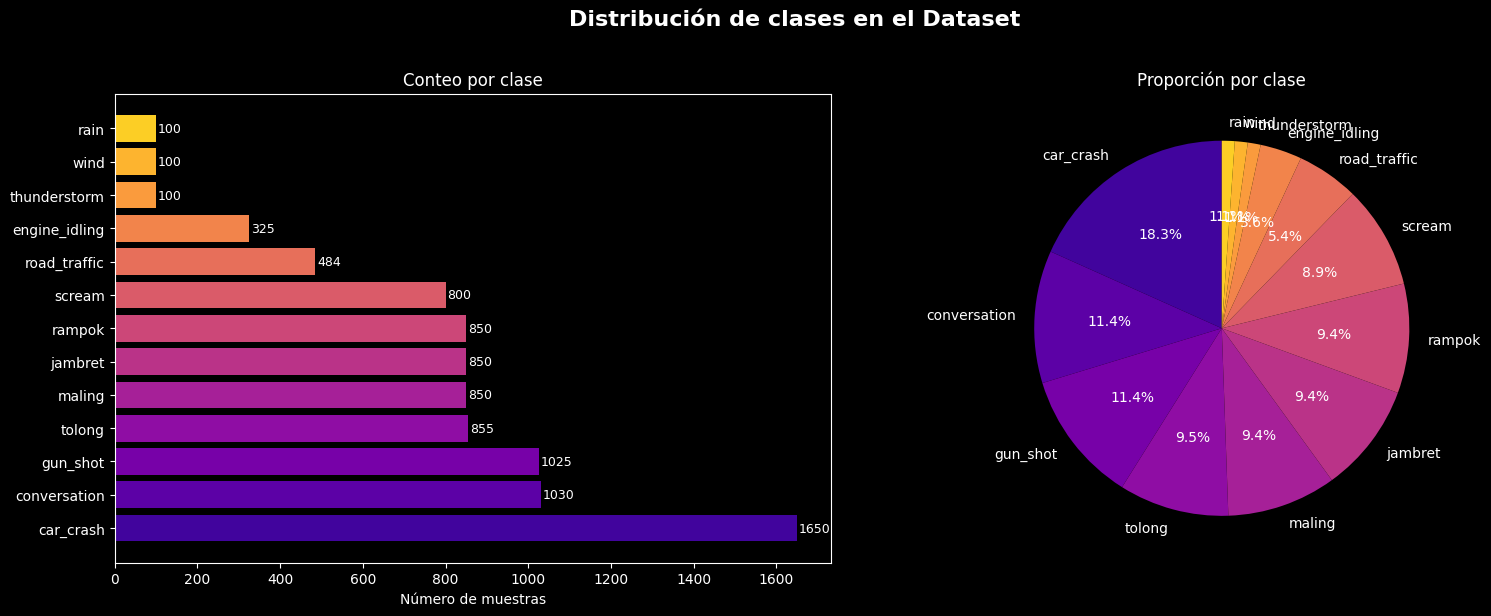

In [23]:
class_counts = df['class'].value_counts()
class_pct = (class_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribución de clases en el Dataset', fontsize=16, fontweight='bold', y=1.02)

# Barplot
bars = axes[0].barh(class_counts.index, class_counts.values,
                    color=plt.cm.plasma(np.linspace(0.1, 0.9, len(class_counts))))
axes[0].set_xlabel('Número de muestras')
axes[0].set_title('Conteo por clase')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=plt.cm.plasma(np.linspace(0.1, 0.9, len(class_counts))),
    startangle=90
)
axes[1].set_title('Proporción por clase')

plt.tight_layout()
plt.show()

In [24]:
# Tabla resumen
summary = pd.DataFrame({'count': class_counts, 'percentage (%)': class_pct})
print('\nResumen de distribución:')
print(summary.to_string())

# ¿Hay desbalance?
imbalance_ratio = class_counts.max() / class_counts.min()
print(f'\nRatio de desbalance (max/min): {imbalance_ratio:.2f}x')
if imbalance_ratio > 5:
    print('Dataset desbalanceado: considerar oversampling/class weights.')
else:
    print('Dataset razonablemente balanceado.')


Resumen de distribución:
               count  percentage (%)
class                               
car_crash       1650           18.29
conversation    1030           11.42
gun_shot        1025           11.36
tolong           855            9.48
maling           850            9.42
jambret          850            9.42
rampok           850            9.42
scream           800            8.87
road_traffic     484            5.37
engine_idling    325            3.60
thunderstorm     100            1.11
wind             100            1.11
rain             100            1.11

Ratio de desbalance (max/min): 16.50x
Dataset desbalanceado: considerar oversampling/class weights.


## **4. Análisis de la duración de los audios**

In [25]:
# Extraer duraciones (puede tardar unos minutos con 9k archivos)
# Si el dataset es grande, muestreamos: df_sample = df.sample(min(1000, len(df)), random_state=42)

def get_duration(filepath):
    try:
        info = sf.info(filepath)
        return info.duration
    except:
        return None

print('Extrayendo duraciones...')
df['duration_s'] = [get_duration(fp) for fp in tqdm(df['filepath'], desc='Duración')]

print(f'\nDuraciones extraídas')
print(f'Archivos con error: {df["duration_s"].isna().sum()}')
df['duration_s'].describe().round(3)

Extrayendo duraciones...


Duración: 100%|██████████| 9019/9019 [00:00<00:00, 9156.82it/s]


Duraciones extraídas
Archivos con error: 0


,duration_s
count,9019.000
mean,2.616
std,3.594
min,0.515
25%,1.010
50%,1.154
75%,3.010
max,60.000


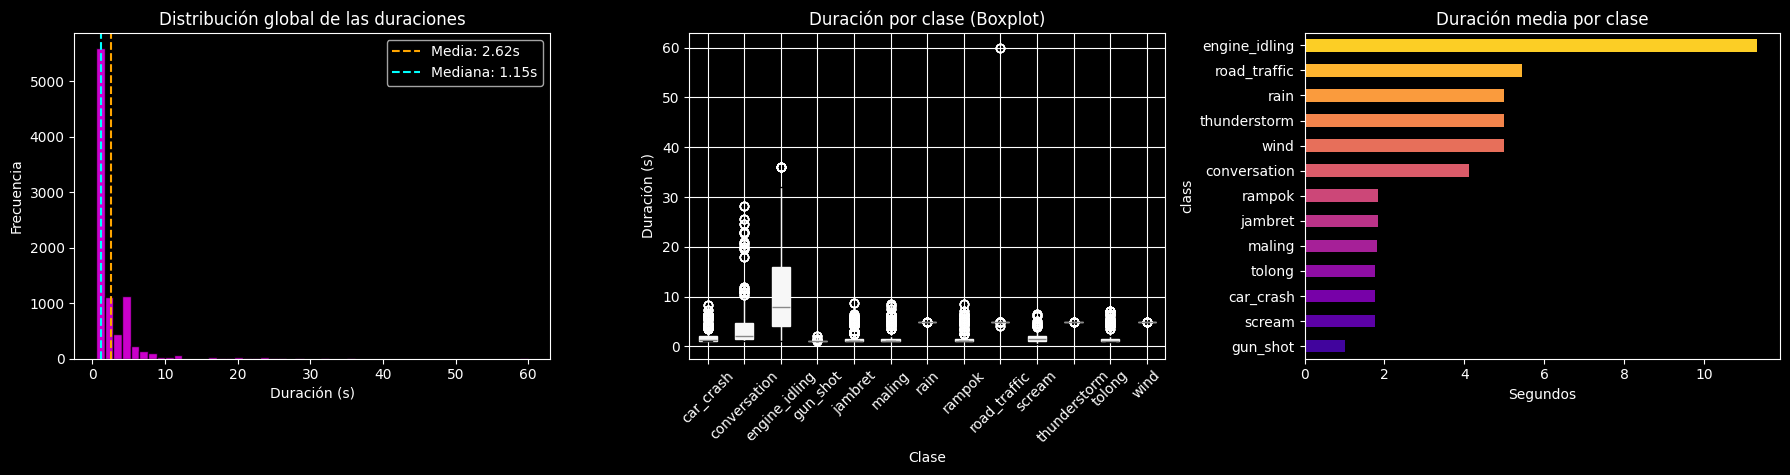

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de duración de los audios', fontsize=15, fontweight='bold')

# Histograma global
axes[0].hist(df['duration_s'].dropna(), bins=50, color='magenta', edgecolor='black', alpha=0.8)
axes[0].axvline(df['duration_s'].mean(), color='orange', linestyle='--', label=f'Media: {df["duration_s"].mean():.2f}s')
axes[0].axvline(df['duration_s'].median(), color='cyan', linestyle='--', label=f'Mediana: {df["duration_s"].median():.2f}s')
axes[0].set_xlabel('Duración (s)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución global de las duraciones')
axes[0].legend()

# Boxplot por clase
df_plot = df.dropna(subset=['duration_s'])
order = df_plot.groupby('class')['duration_s'].median().sort_values().index
df_plot.boxplot(column='duration_s', by='class', ax=axes[1],
                patch_artist=True, rot=45)
axes[1].set_title('Duración por clase (Boxplot)')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Duración (s)')
plt.sca(axes[1])
plt.suptitle('')

# Duración media por clase
mean_dur = df_plot.groupby('class')['duration_s'].mean().sort_values()
mean_dur.plot(kind='barh', ax=axes[2],
              color=plt.cm.plasma(np.linspace(0.1, 0.9, len(mean_dur))))
axes[2].set_title('Duración media por clase')
axes[2].set_xlabel('Segundos')
plt.tight_layout()
plt.show()

In [27]:
# Detectar outliers de duración
q_low = df['duration_s'].quantile(0.01)
q_high = df['duration_s'].quantile(0.99)
outliers_dur = df[(df['duration_s'] < q_low) | (df['duration_s'] > q_high)]
print(f'\nArchivos con duración fuera del rango p1-p99: {len(outliers_dur)}')
print(f'Rango normal: [{q_low:.2f}s, {q_high:.2f}s]')


Archivos con duración fuera del rango p1-p99: 111
Rango normal: [1.00s, 20.01s]


## **5. Análisis de sample rate y canales**

In [28]:
def get_audio_meta(filepath):
    try:
        info = sf.info(filepath)
        return info.samplerate, info.channels
    except:
        return None, None

print('Extrayendo metadatos de audio...')
meta = [get_audio_meta(fp) for fp in tqdm(df['filepath'], desc='Metadatos')]
df['sample_rate'] = [m[0] for m in meta]
df['channels'] = [m[1] for m in meta]

print('\nDistribución de sample rates:')
print(df['sample_rate'].value_counts())

print('\nDistribución de canales (1=Mono, 2=Stereo):')
print(df['channels'].value_counts())

Extrayendo metadatos de audio...


Metadatos: 100%|██████████| 9019/9019 [00:00<00:00, 15003.08it/s]


Distribución de sample rates:
sample_rate
44100    8794
48000     214
96000      10
22050       1
Name: count, dtype: int64

Distribución de canales (1=Mono, 2=Stereo):
channels
1    8962
2      57
Name: count, dtype: int64


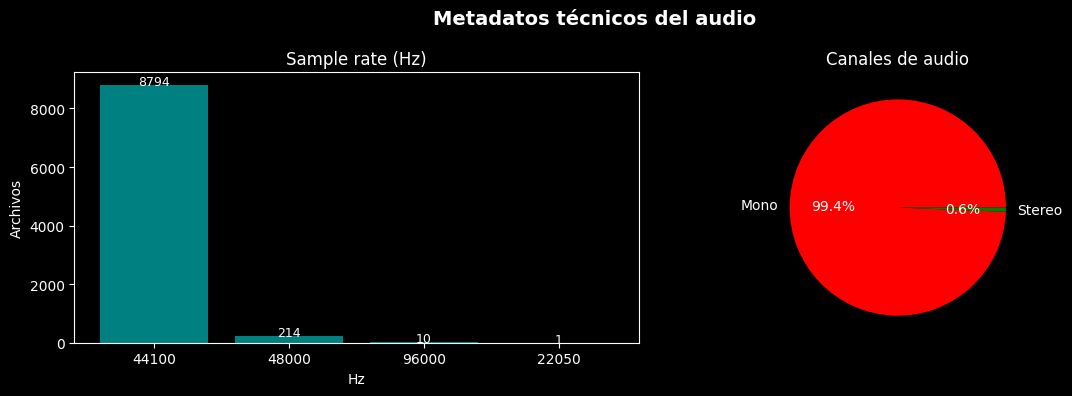


Hay 225 archivos con sample rate no estándar --> requieren resampleo.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Metadatos técnicos del audio', fontsize=14, fontweight='bold')

sr_counts = df['sample_rate'].value_counts()
axes[0].bar(sr_counts.index.astype(str), sr_counts.values, color='teal')
axes[0].set_title('Sample rate (Hz)')
axes[0].set_xlabel('Hz')
axes[0].set_ylabel('Archivos')
for i, v in enumerate(sr_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

ch_counts = df['channels'].value_counts()
labels = ['Mono' if c == 1 else 'Stereo' if c == 2 else f'{c}ch' for c in ch_counts.index]
axes[1].pie(ch_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['red', 'green'])
axes[1].set_title('Canales de audio')
plt.tight_layout()
plt.show()

non_std = df[df['sample_rate'] != df['sample_rate'].mode()[0]]
if len(non_std) > 0:
    print(f'\nHay {len(non_std)} archivos con sample rate no estándar --> requieren resampleo.')
else:
    print('Todos los archivos tienen el mismo sample rate.')

## **6. Visualización de formas de onda (waveforms)**

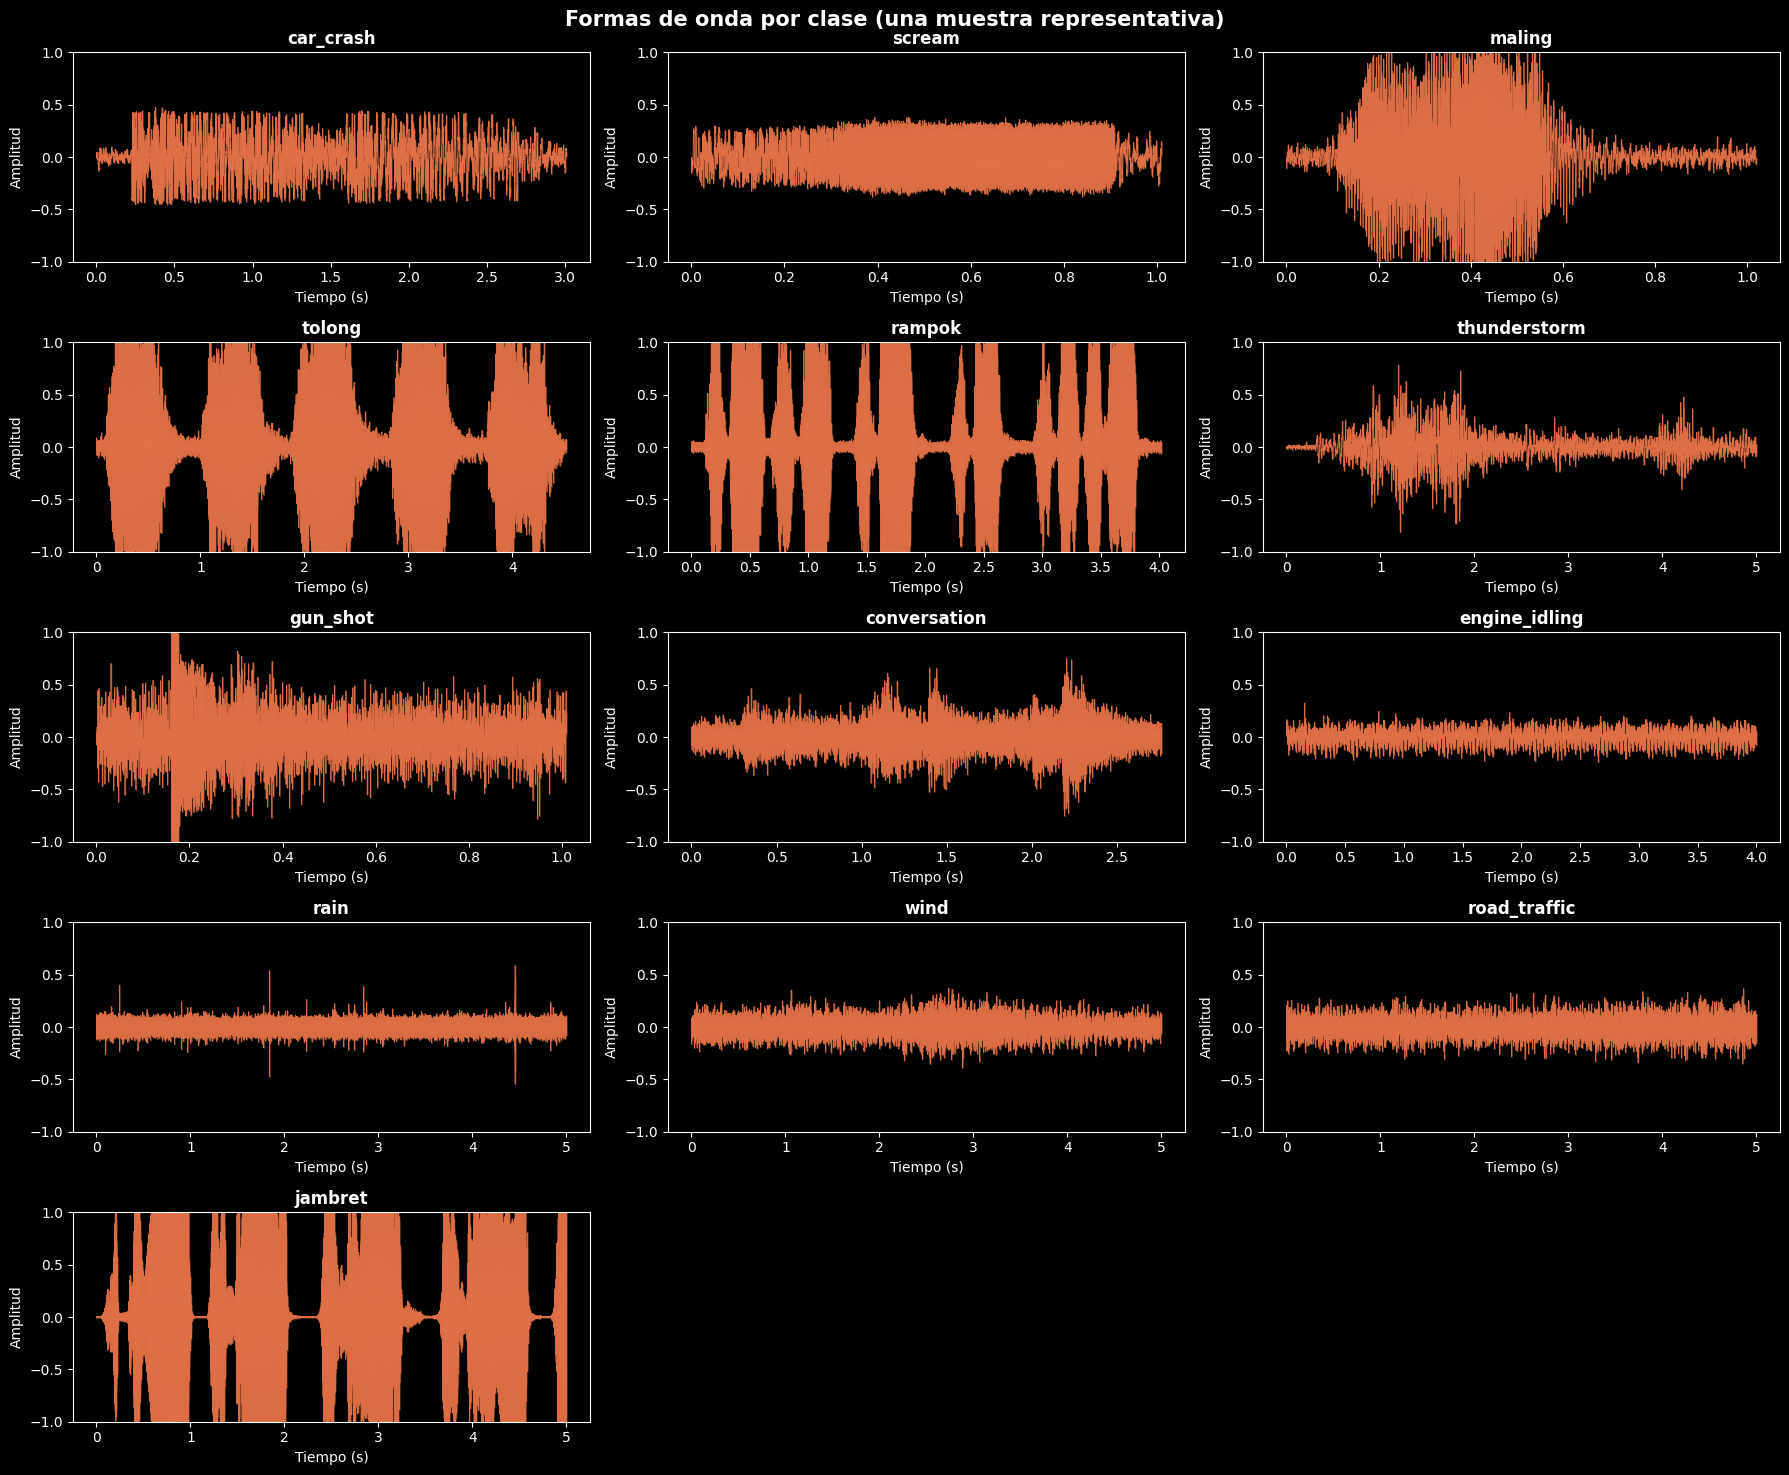

In [30]:
def plot_waveforms(df, n_classes=None, sample_per_class=1):
    classes = df['class'].unique()
    if n_classes:
        classes = classes[:n_classes]

    n_cols = 3
    n_rows = int(np.ceil(len(classes) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
    fig.suptitle('Formas de onda por clase (una muestra representativa)',
                 fontsize=15, fontweight='bold')
    axes = axes.flatten()

    for i, cls in enumerate(classes):
        sample = df[df['class'] == cls].sample(1).iloc[0]
        try:
            y, sr = librosa.load(sample['filepath'], duration=5.0, sr=None)
            t = np.linspace(0, len(y)/sr, len(y))
            axes[i].plot(t, y, linewidth=0.5, color='coral', alpha=0.8)
            axes[i].fill_between(t, y, alpha=0.3, color='coral')
            axes[i].set_title(cls, fontweight='bold')
            axes[i].set_xlabel('Tiempo (s)')
            axes[i].set_ylabel('Amplitud')
            axes[i].set_ylim(-1, 1)
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error: {e}', ha='center', va='center',
                        transform=axes[i].transAxes)
            axes[i].set_title(cls)

    # Ocultar subplots vacíos
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_waveforms(df)

## **7. Espectrogramas y representaciones frecuenciales**

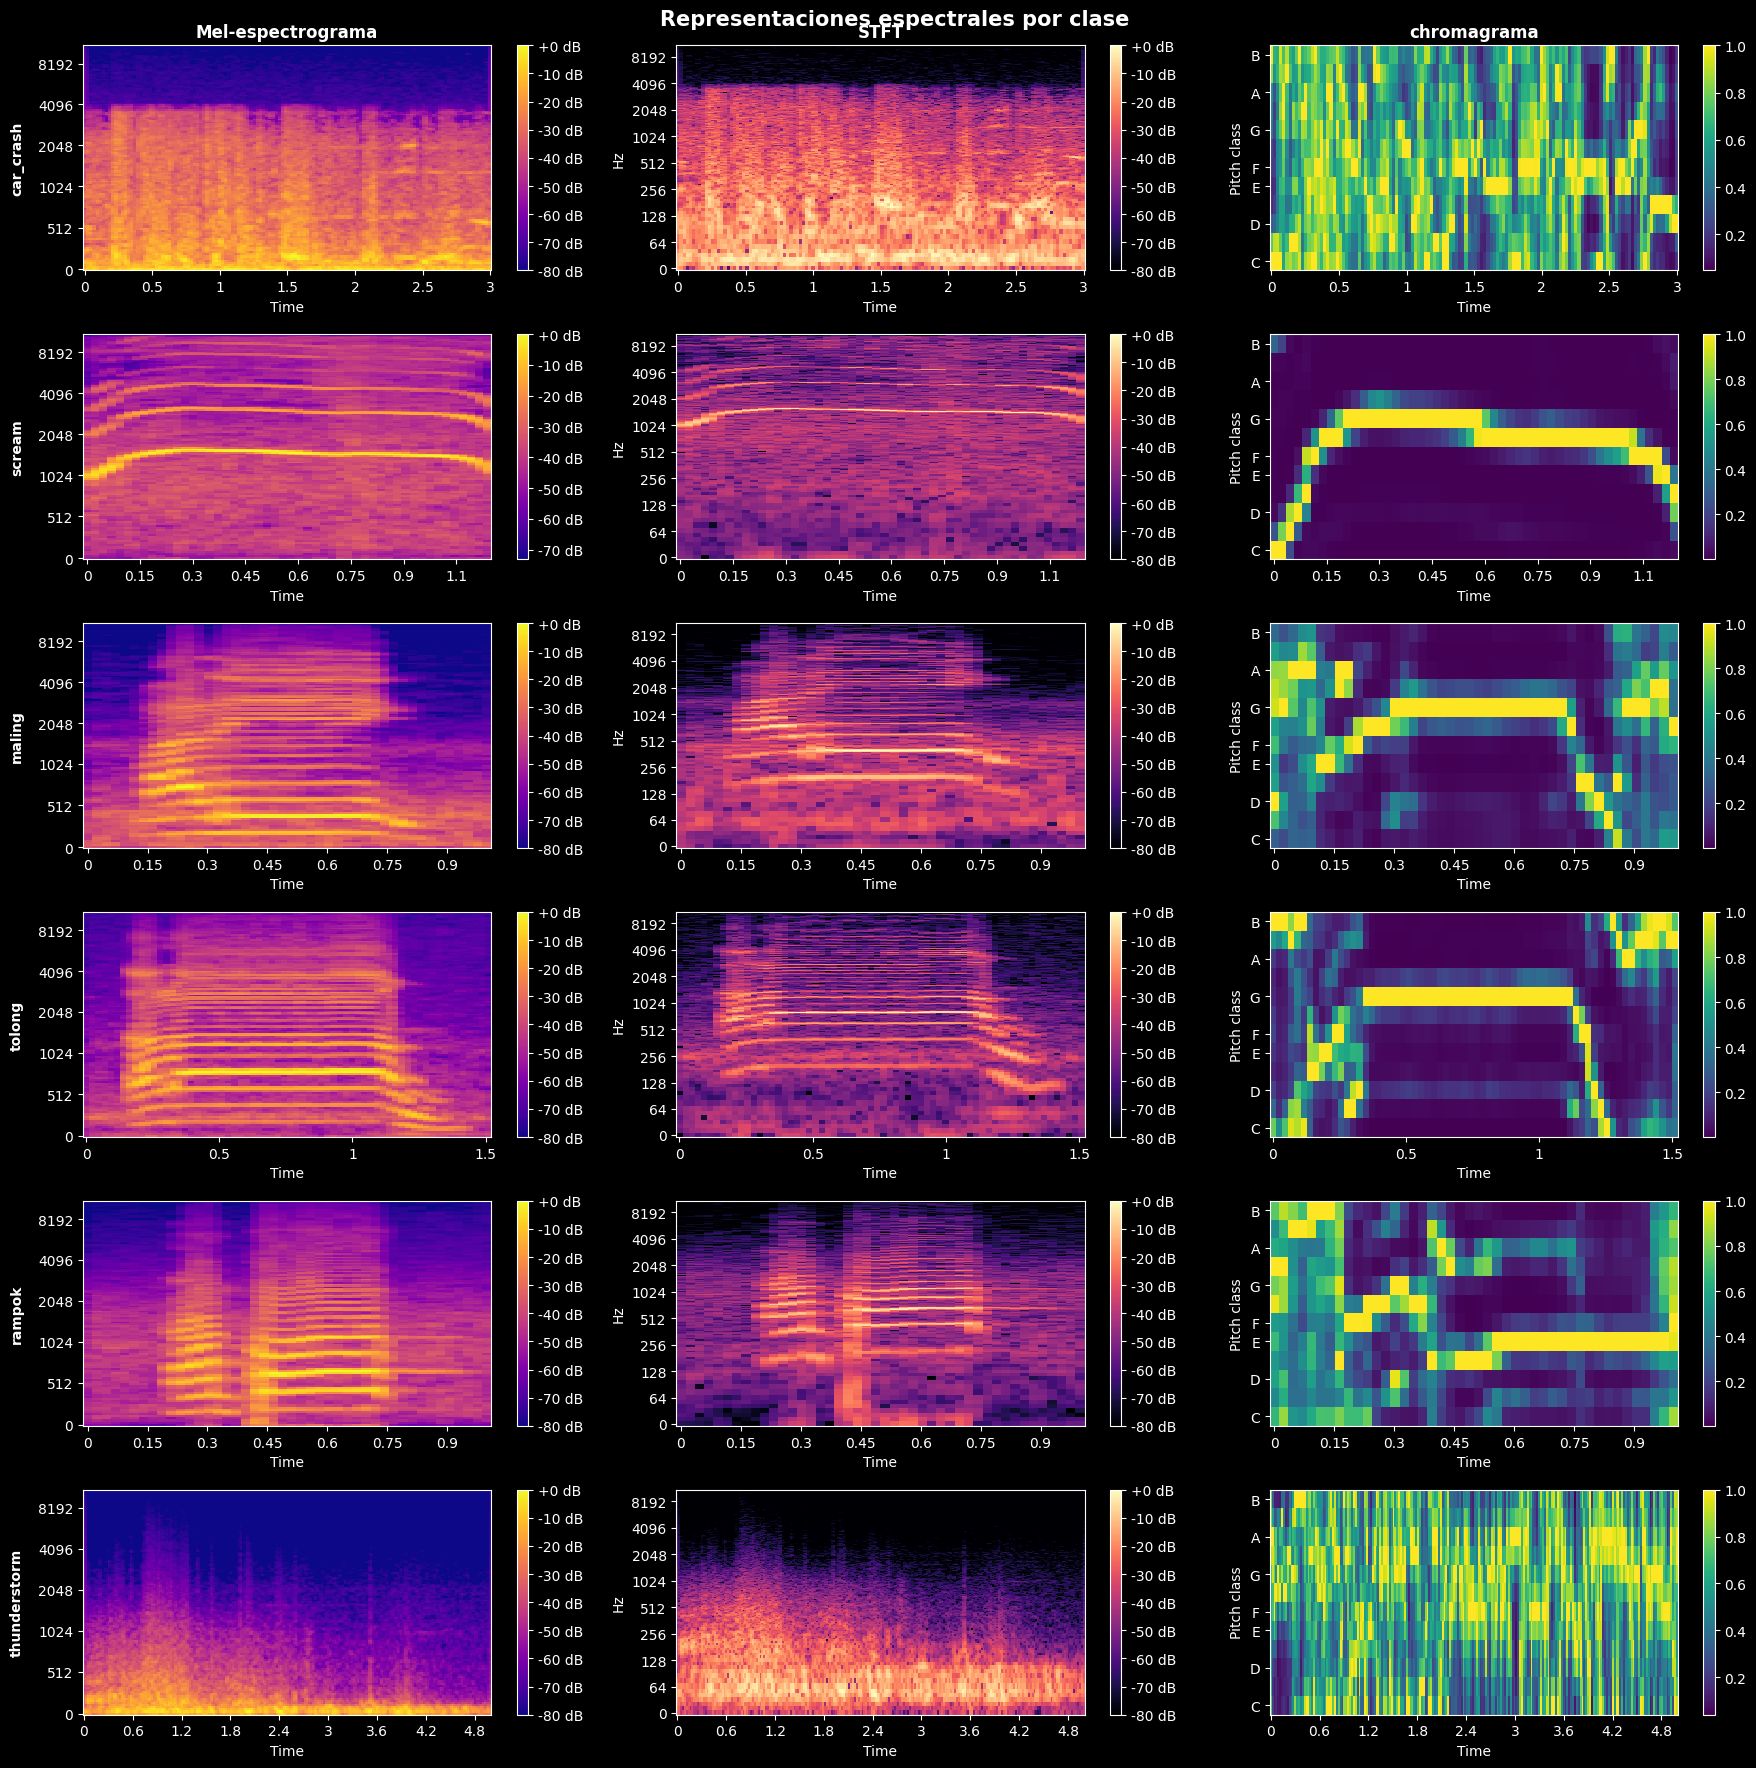

In [31]:
def plot_spectrograms(df, classes_to_plot=None):
    """Muestra mel-espectrogramas, espectrogramas STFT y chromas para cada clase."""
    if classes_to_plot is None:
        classes_to_plot = df['class'].unique()[:6] # Las primeras 6 para no saturar

    fig, axes = plt.subplots(len(classes_to_plot), 3,
                              figsize=(18, len(classes_to_plot) * 3))
    fig.suptitle('Representaciones espectrales por clase',
                 fontsize=15, fontweight='bold')

    col_titles = ['Mel-espectrograma', 'STFT', 'chromagrama']
    for j, ct in enumerate(col_titles):
        axes[0, j].set_title(ct, fontweight='bold', fontsize=12)

    for i, cls in enumerate(classes_to_plot):
        sample = df[df['class'] == cls].sample(1).iloc[0]
        try:
            y, sr = librosa.load(sample['filepath'], duration=5.0, sr=22050)

            # Mel-espectrograma
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            img = librosa.display.specshow(mel_db, sr=sr, x_axis='time',
                                            y_axis='mel', ax=axes[i, 0],
                                            cmap='plasma')
            fig.colorbar(img, ax=axes[i, 0], format='%+2.0f dB')
            axes[i, 0].set_ylabel(cls, fontweight='bold', rotation=90, labelpad=10)

            # STFT
            D = np.abs(librosa.stft(y))
            D_db = librosa.amplitude_to_db(D, ref=np.max)
            img2 = librosa.display.specshow(D_db, sr=sr, x_axis='time',
                                             y_axis='log', ax=axes[i, 1],
                                             cmap='magma')
            fig.colorbar(img2, ax=axes[i, 1], format='%+2.0f dB')

            # Chromagrama
            chroma = librosa.feature.chroma_stft(y=y, sr=sr)
            img3 = librosa.display.specshow(chroma, sr=sr, x_axis='time',
                                             y_axis='chroma', ax=axes[i, 2],
                                             cmap='viridis')
            fig.colorbar(img3, ax=axes[i, 2])
        except Exception as e:
            for j in range(3):
                axes[i, j].text(0.5, 0.5, str(e), ha='center', va='center',
                               transform=axes[i, j].transAxes, fontsize=8)

    plt.tight_layout()
    plt.show()

plot_spectrograms(df)

## **8. Extracción de features: MFCCs**

- Los **MFCCs (Mel-Frequency Cepstral Coefficients)** son las features más utilizadas en clasificación de audio.

In [32]:
def extract_features(filepath, n_mfcc=40, duration=5.0, sr_target=22050):
    """Extrae MFCCs + features adicionales de un archivo WAV."""
    try:
        y, sr = librosa.load(filepath, duration=duration, sr=sr_target)

        # MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_mean = np.mean(mfccs, axis=1)
        mfccs_std = np.std(mfccs, axis=1)

        # Features adicionales
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        rms = np.mean(librosa.feature.rms(y=y))
        spectral_c = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        spectral_b = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))

        features = np.concatenate([
            mfccs_mean, mfccs_std,
            [zcr, rms, spectral_c, spectral_b, rolloff]
        ])
        return features, None
    except Exception as e:
        return None, str(e)

# Extraer features para todo el dataset (puede tardar ~10-20 min)
# Para el EDA, podemos usar una muestra representativa:
SAMPLE_SIZE = min(500, len(df)) # Ajustar según el tiempo disponible
df_sample = df.groupby('class', group_keys=False).apply(
    lambda x: x.sample(min(len(x), SAMPLE_SIZE // df['class'].nunique()), random_state=42)
).reset_index(drop=True)

print(f'Extrayendo features de {len(df_sample)} archivos...')
features_list, errors = [], []
for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc='MFCCs'):
    feat, err = extract_features(row['filepath'])
    features_list.append(feat)
    errors.append(err)

df_sample['features'] = features_list
df_sample['error'] = errors

# Filtrar errores
df_feats = df_sample[df_sample['features'].notna()].copy()
print(f'\nFeatures extraídas: {len(df_feats)}')
print(f'Errores: {df_sample["error"].notna().sum()}')

# Construir una matriz de features
X = np.stack(df_feats['features'].values)
y_labels = df_feats['class'].values
print(f'\nDimensiones de la matriz de features: {X.shape}')
print(f'(n_samples x n_features: {X.shape[0]} x {X.shape[1]})')

Extrayendo features de 494 archivos...


MFCCs: 100%|██████████| 494/494 [00:13<00:00, 36.19it/s]


Features extraídas: 494
Errores: 0

Dimensiones de la matriz de features: (494, 85)
(n_samples x n_features: 494 x 85)


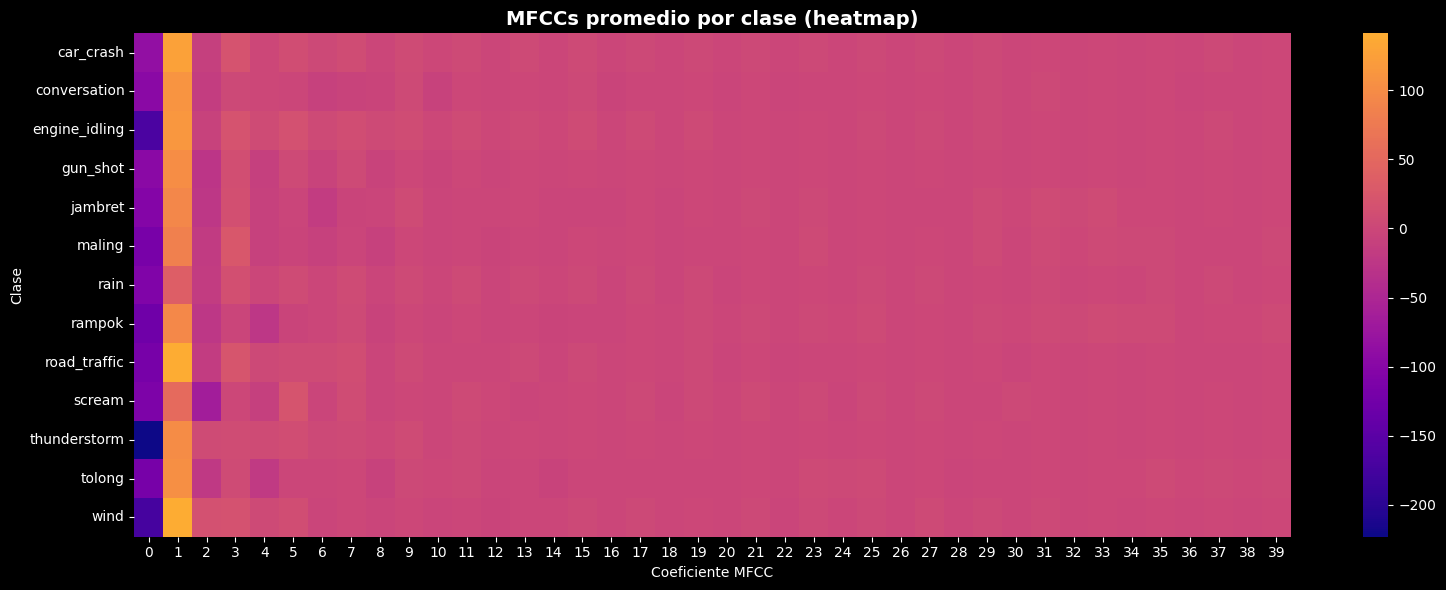

In [33]:
# Visualizar MFCCs promedio por clase
n_mfcc = 40
mfcc_cols = [f'mfcc_mean_{i}' for i in range(n_mfcc)]

df_mfcc = pd.DataFrame(X[:, :n_mfcc], columns=mfcc_cols)
df_mfcc['class'] = y_labels

mfcc_mean_class = df_mfcc.groupby('class')[mfcc_cols].mean()

plt.figure(figsize=(16, 6))
sns.heatmap(mfcc_mean_class, cmap='plasma', center=0,
            xticklabels=[i for i in range(n_mfcc)],
            yticklabels=mfcc_mean_class.index)
plt.title('MFCCs promedio por clase (heatmap)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente MFCC')
plt.ylabel('Clase')
plt.tight_layout()
plt.show()

## **9. Análisis de energía y Zero Crossing Rate**

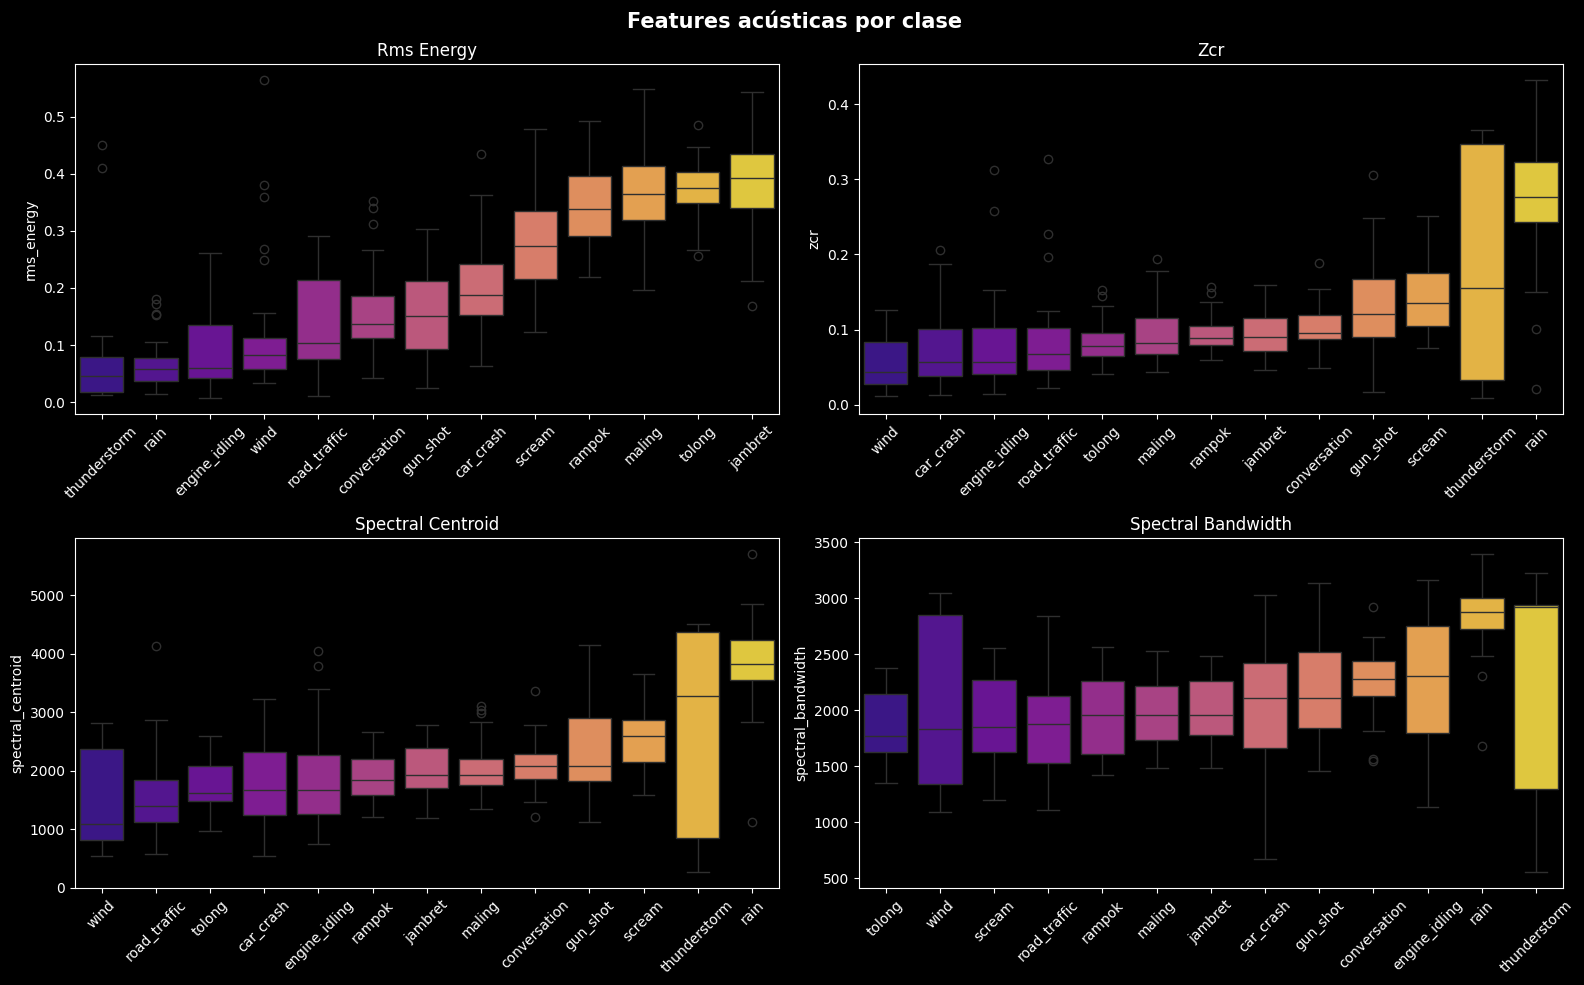

In [34]:
# Índices de las features adicionales en la matriz X
idx_zcr = n_mfcc * 2 # ZCR
idx_rms = n_mfcc * 2 + 1 # RMS energy
idx_sc = n_mfcc * 2 + 2 # Spectral centroid
idx_sb = n_mfcc * 2 + 3 # Spectral bandwidth
idx_ro = n_mfcc * 2 + 4 # Spectral rolloff

df_acoustic = pd.DataFrame({
    'class': y_labels,
    'zcr' : X[:, idx_zcr],
    'rms_energy': X[:, idx_rms],
    'spectral_centroid': X[:, idx_sc],
    'spectral_bandwidth': X[:, idx_sb],
    'spectral_rolloff': X[:, idx_ro]
})

features_to_plot = ['rms_energy', 'zcr', 'spectral_centroid', 'spectral_bandwidth']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Features acústicas por clase', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    order = df_acoustic.groupby('class')[feat].median().sort_values().index
    sns.boxplot(data=df_acoustic, x='class', y=feat, ax=axes[i],
                order=order, palette='plasma')
    axes[i].set_title(feat.replace('_', ' ').title())
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

## **10. Detección de anomalías y calidad**

In [35]:
# Archivos silenciosos (RMS muy bajo)
rms_threshold = 0.001
silent_files = df_acoustic[df_acoustic['rms_energy'] < rms_threshold]
print(f'Archivos posiblemente silenciosos (RMS < {rms_threshold}): {len(silent_files)}')
if len(silent_files) > 0:
    print(silent_files['class'].value_counts().to_string())

# Archivos con saturación (RMS muy alto)
rms_high = df_acoustic['rms_energy'].quantile(0.99)
saturated_files = df_acoustic[df_acoustic['rms_energy'] > rms_high]
print(f'\nArchivos con energía extremadamente alta (p99): {len(saturated_files)}')

Archivos posiblemente silenciosos (RMS < 0.001): 0

Archivos con energía extremadamente alta (p99): 5


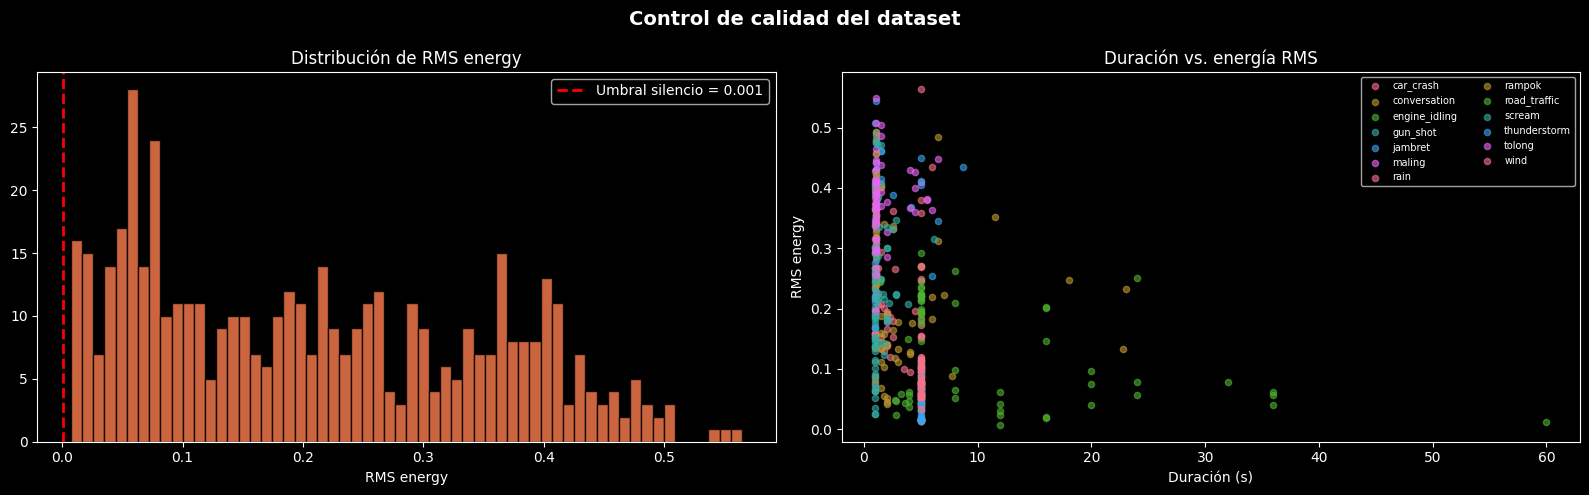

In [36]:
# Distribución de RMS por clase
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Control de calidad del dataset', fontsize=14, fontweight='bold')

axes[0].hist(df_acoustic['rms_energy'], bins=60, color='coral', edgecolor='black', alpha=0.8)
axes[0].axvline(rms_threshold, color='red', linestyle='--', linewidth=2,
                label=f'Umbral silencio = {rms_threshold}')
axes[0].set_title('Distribución de RMS energy')
axes[0].set_xlabel('RMS energy')
axes[0].legend()

# Duración vs. energía por clase
if 'duration_s' in df_feats.columns:
    scatter_df = df_feats.copy()
    scatter_df['rms'] = X[:, idx_rms]
    for cls in scatter_df['class'].unique():
        mask = scatter_df['class'] == cls
        axes[1].scatter(scatter_df.loc[mask, 'duration_s'],
                        scatter_df.loc[mask, 'rms'],
                        label=cls, alpha=0.6, s=20)
    axes[1].set_title('Duración vs. energía RMS')
    axes[1].set_xlabel('Duración (s)')
    axes[1].set_ylabel('RMS energy')
    axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

In [37]:
# Resumen de calidad
print('\nResumen de la calidad del dataset:')
print(f'- Total archivos analizados: {len(df_feats)}')
print(f'- Posiblemente silenciosos: {len(silent_files)} ({len(silent_files)/len(df_feats)*100:.2f} %)')
print(f'- Outliers de energía alta: {len(saturated_files)} ({len(saturated_files)/len(df_feats)*100:.2f} %)')


Resumen de la calidad del dataset:
- Total archivos analizados: 494
- Posiblemente silenciosos: 0 (0.00 %)
- Outliers de energía alta: 5 (1.01 %)


## **11. Correlaciones entre features y reducción dimensional**

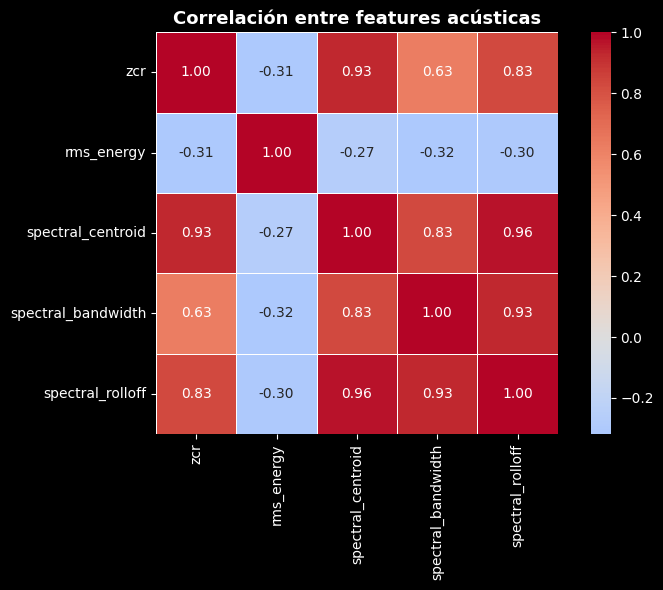

In [38]:
# Matriz de correlación de features acústicas
corr = df_acoustic[['zcr', 'rms_energy', 'spectral_centroid',
                     'spectral_bandwidth', 'spectral_rolloff']].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlación entre features acústicas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

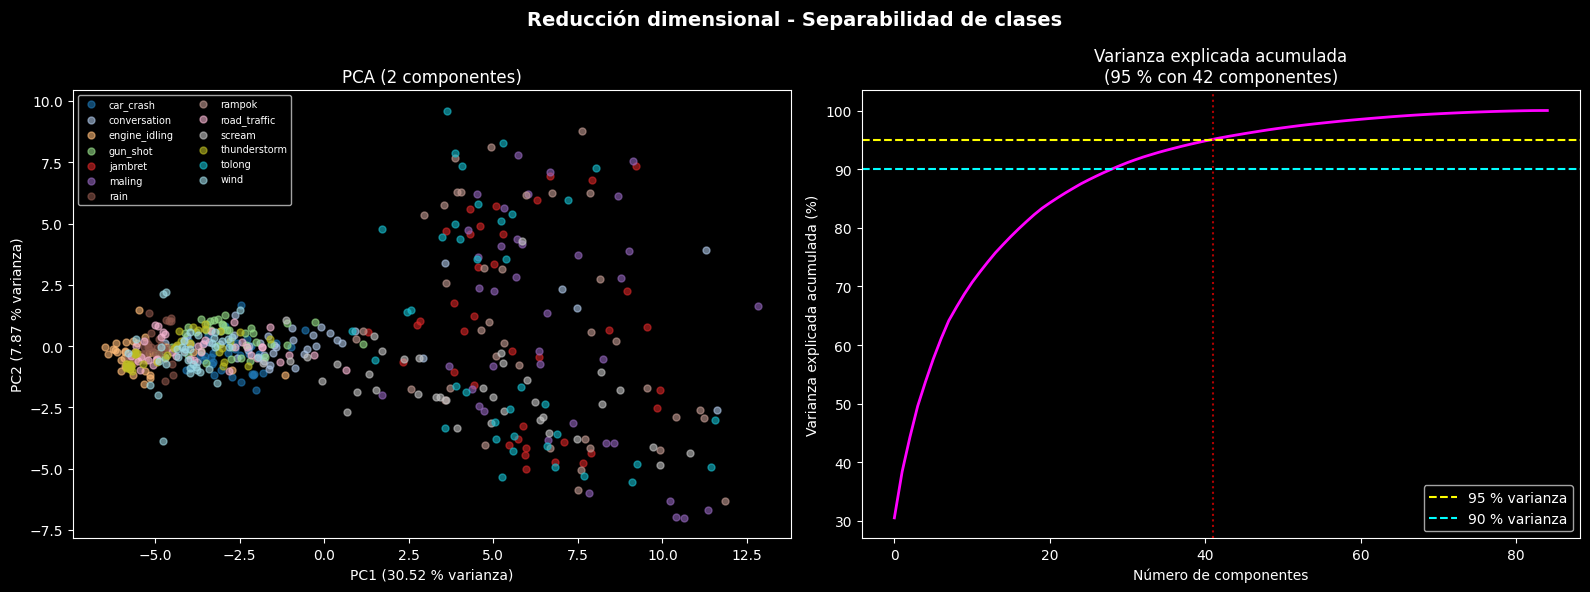

In [39]:
# PCA: visualización 2D de separabilidad de clases
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Reducción dimensional - Separabilidad de clases',
             fontsize=14, fontweight='bold')

# PCA
classes_unique = np.unique(y_labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(classes_unique)))
for cls, color in zip(classes_unique, colors):
    mask = y_labels == cls
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=cls, color=color, alpha=0.6, s=25)
axes[0].set_xlabel(f'PC1 ({explained[0]:.2f} % varianza)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.2f} % varianza)')
axes[0].set_title('PCA (2 componentes)')
axes[0].legend(fontsize=7, ncol=2)

# Varianza explicada acumulada (PCA completo)
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(cumvar, color='magenta', linewidth=2)
axes[1].axhline(95, color='yellow', linestyle='--', label='95 % varianza')
axes[1].axhline(90, color='cyan', linestyle='--', label='90 % varianza')
idx_95 = np.where(cumvar >= 95)[0][0] if any(cumvar >= 95) else len(cumvar)-1
axes[1].axvline(idx_95, color='red', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza explicada acumulada (%)')
axes[1].set_title(f'Varianza explicada acumulada\n(95 % con {idx_95+1} componentes)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [40]:
print(f'Componentes para explicar el 95 % de varianza: {idx_95 + 1}')

Componentes para explicar el 95 % de varianza: 42


Calculando t-SNE (puede tardar 1-3 min)...


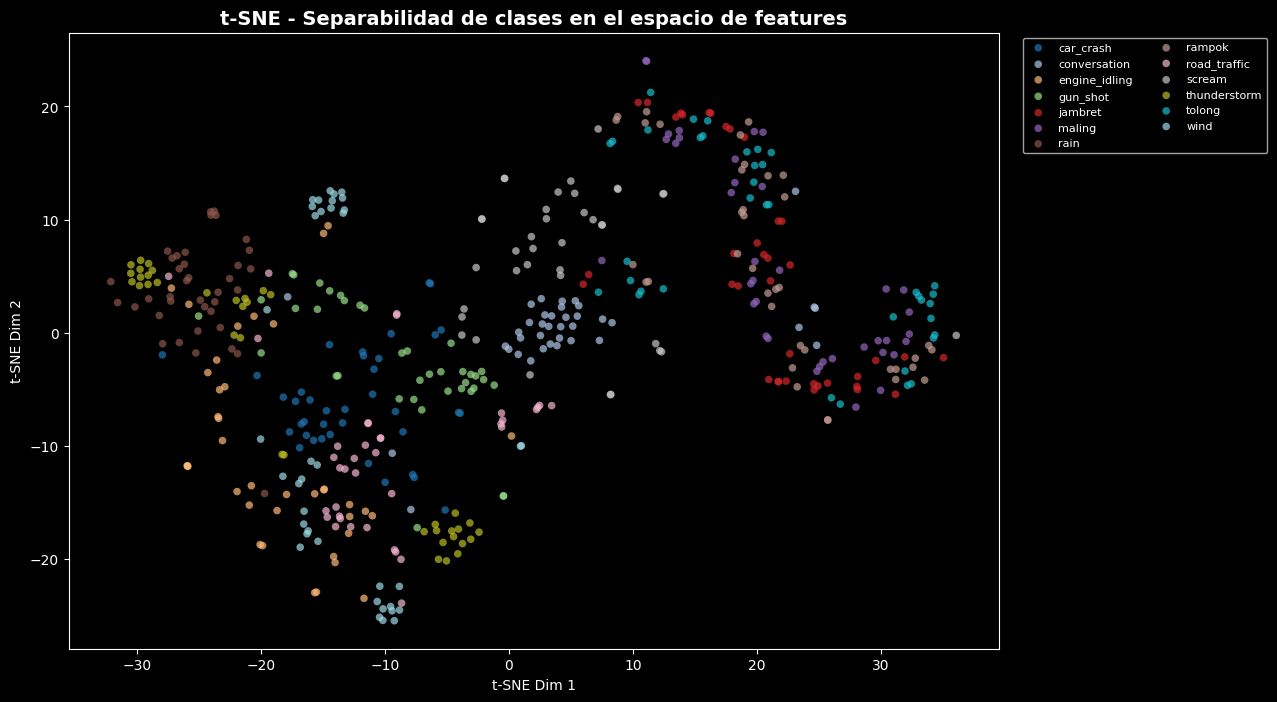

In [41]:
# t-SNE --> requiere más tiempo
print('Calculando t-SNE (puede tardar 1-3 min)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
for cls, color in zip(classes_unique, colors):
    mask = y_labels == cls
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=cls, color=color, alpha=0.7, s=30, edgecolors='none')
plt.title('t-SNE - Separabilidad de clases en el espacio de features',
          fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.legend(fontsize=8, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

## **12. Conclusiones**

In [42]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║                              CONCLUSIONES                                ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  DATASET                                                                 ║
║  • 9.089 archivos WAV distribuidos en 13 clases.                         ║
║  • Es la versión aumentada/preprocesada del dataset raw.                 ║
║                                                                          ║
║  BALANCE DE CLASES                                                       ║
║  • Si ratio > 5x --> usar class_weight='balanced' o SMOTE.               ║
║                                                                          ║
║  DURACIÓN                                                                ║
║  • Variable entre clases --> normalizar a longitud fija (e.g. 4s).       ║
║  • Estrategia: padding/truncado o ventanas deslizantes.                  ║
║                                                                          ║
║  SAMPLE RATE Y CANALES                                                   ║
║  • Recomendación: resamplear todo a 22.050 Hz, convertir a mono.         ║
║                                                                          ║
║  FEATURES RECOMENDADAS PARA EL MODELADO                                  ║
║  • MFCCs (40 coeficientes) - discriminación media-alta.                  ║
║  • Mel-espectrogramas - input ideal para CNNs.                           ║
║  • ZCR + RMS                                                             ║
║                                                                          ║
║  ARQUITECTURAS SUGERIDAS                                                 ║
║  1. CNN 2D sobre mel-espectrogramas.                                     ║
║  2. CNN + LSTM para capturar el contexto temporal.                       ║
║  3. Ensemble con features clásicas (MFCC --> XGBoost/RF)                 ║
║                                                                          ║
║  CONSIDERACIONES ADICIONALES                                             ║
║  • Data augmentation: time stretch, pitch shift, additive noise.         ║
║  • Validación: stratified K-Fold por clase.                              ║
║  • Métrica principal: F1-macro (clases desbalanceadas).                  ║
║  • Para producción: ventana deslizante en stream de audio real.          ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════╗
║                              CONCLUSIONES                                ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  DATASET                                                                 ║
║  • 9.089 archivos WAV distribuidos en 13 clases.                         ║
║  • Es la versión aumentada/preprocesada del dataset raw.                 ║
║                                                                          ║
║  BALANCE DE CLASES                                                       ║  
║  • Si ratio > 5x --> usar class_weight='balanced' o SMOTE.               ║
║                                                                          ║
║  DURACIÓN                                                                ║
║  • Variable entre clases --> normalizar a longitud fija (e.g. 4s).     

In [43]:
# Guardar resumen del dataset a un .CSV para referencia
summary_export = df.groupby('class').agg(
    count=('filename', 'count'),
    mean_duration_s=('duration_s', 'mean'),
    std_duration_s=('duration_s', 'std'),
    mean_size_kb=('size_kb', 'mean')
).round(3)

summary_export.to_csv('crime_detection_summary.csv')
print('Resumen guardado en crime_detection_summary.csv')
summary_export

Resumen guardado en crime_detection_summary.csv


,count,mean_duration_s,std_duration_s,mean_size_kb
class,,,,
car_crash,1650,1.762,1.189,151.815
conversation,1030,4.113,4.883,354.325
engine_idling,325,11.328,9.428,1404.728
gun_shot,1025,1.019,0.080,88.518
jambret,850,1.836,1.601,158.143
maling,850,1.811,1.685,156.042
rain,100,5.000,0.000,430.710
rampok,850,1.851,1.667,159.446
road_traffic,484,5.446,4.986,472.924
